## Law Gender Bias - 2 OBJECTIVES

### Multi Task Learning

* **Dataset:** Law Gender Bias
* **Task :** Classification
* **Target 1:** Bias - general
* **Target 2:** Bias with a target

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import random
import numpy as np

import torch
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer
from typing import Any
from collections.abc import Callable
from sklearn.model_selection import train_test_split

/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes
from machinemoo.analysis.metrics import compute_hypervolume_progress

from scalarization import NLPScalarization

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


In [4]:
# Setting a seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

## Dataset and Model

In [5]:
def prepare_datasets(json_path: str): 

    with open(json_path, 'r') as f:
        data = json.load(f)

    train_keys, test_keys = train_test_split(list(data.keys()), test_size=0.1, random_state=42)
    train_keys, val_keys = train_test_split(train_keys, test_size=0.2, random_state=42)

    train_data = {key: data[key] for key in train_keys}
    val_data= {key: data[key] for key in val_keys}
    test_data = {key: data[key] for key in test_keys}
    
    return train_data, val_data, test_data 

In [6]:
#train_data, val_data, test_data = prepare_datasets('../ap/files/annotate_filled.json')
train_data, val_data, test_data = prepare_datasets('../lesao/files/annotate_filled.json')   

In [7]:
train_data

{'2018-10-25_00182546220168260001': {'nome_arquivo': '2018-10-25_00182546220168260001',
  'apelante': ['gtcs'],
  'apelante_genero': ['masc_trans'],
  'apelado': ['rgcs'],
  'crime': ['cp129p9'],
  'vitima': ['irmao'],
  'vitima_genero': ['masc_trans'],
  'pena_original': ['0'],
  'requer': ['cond'],
  'requer_subsid': [''],
  'requer_motivo': [''],
  'mp_pj': ['s', 'n'],
  'resultado': ['s'],
  'resultado_razoes': ['aut_mater'],
  'pena_atual': ['3'],
  'vies': [''],
  'vies_alvo': [''],
  'vies_contexto': ['Assim, diante desse consistente conjunto probante, deve prevalecer a incontroversa palavra da vítima Afinal de contas, e como se sabe, crimes desta natureza, via de regra, acontecem de maneira clandestina, sem os olhares de testemunhas, razão pela qual ficam as palavras da vítima dotadas de valor extraordinário, ainda mais porque tais dizeres não destoam, em absoluto, dos demais elementos probatórios acostados aos autos, mormente ao se considerar o exame de corpo de delito mencion

In [8]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


In [9]:
# Cell 3: Dataset class
MODEL_NAME = "neuralmind/bert-base-portuguese-cased"
MAX_LEN = 512
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, cache_dir="transformers")

class MultiTaskDataset(Dataset):
    """
    Flexible dataset for multi-task classification from a JSON-like dict format.
    Supports multiple text chunks and multiple label fields.
    """

    def __init__(self,
                 data: dict,
                 tokenizer,
                 max_length: int = 128,
                 chunk_field: str = "vies_contexto",
                 label_extractors = {}
                 ) -> None:
        """
        Parameters:
        - data: loaded JSON-like dict
        - tokenizer: HuggingFace tokenizer
        - max_length: max token length
        - chunk_field: which text chunk to use (e.g., 'vies_contexto')
        - label_extractors: dictionary mapping task names to label extraction functions
        - data_type: optional, used for augmentation
        """
        self.tokenizer = tokenizer
        self.max_length = max_length

        self.texts = []
        self.labels = {task: [] for task in label_extractors}

        for item in data.values():
            for text in item.get(chunk_field, []):
                self.texts.append(text)
                for task_name, extractor_fn in label_extractors.items():
                    label = extractor_fn(item)
                    self.labels[task_name].append(label)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        encoding = self.tokenizer.encode_plus(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            add_special_tokens=True
        )

        item = {
            'input_ids': torch.LongTensor(encoding['input_ids']),
            'attention_mask': torch.LongTensor(encoding['attention_mask'])
        }

        for task_name in self.labels:
            item[f'{task_name}'] = torch.tensor(self.labels[task_name][idx], dtype=torch.long)

        return item

In [ ]:
def key_presence_extractor(key: str, subkey: str = "") -> Callable[[dict[str, Any]], int]:
    """
    Returns a function that checks if `key` (and optionally `subkey`) is present in the sample.
    Useful for binary presence labels.
    """
    def extractor(sample: dict[str, Any]) -> int:
        if subkey != "":
            result = subkey in sample.get(key, {})
        else:
            val = sample.get(key, [""])[0] if isinstance(sample.get(key), list) else sample.get(key)
            result = bool(val)
        return int(result)
    return extractor

<>:7: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
<>:7: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
/tmp/ipykernel_1280859/2534555771.py:7: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
  if subkey is not "":


In [11]:
label_extractors = {
    "bias": key_presence_extractor("vies"),
    #"task_2": key_presence_extractor("apelante_genero", subkey="fem")
    "bias_woman": key_presence_extractor("vies_alvo", subkey="mul"),
    #"task_2": key_presence_extractor("vies_alvo", subkey="test")
    #"task_2": key_presence_extractor("vitima_genero", subkey="masc")
    #"task_2": key_presence_extractor("vies_alvo", subkey="reu")
    #"task_2": key_presence_extractor("mp_pj", subkey="s") #bom 4 soluções
    #"task_2": key_presence_extractor("pena_atual", subkey="idem")
    #"task_2": key_presence_extractor("resultado", subkey="s")
    #"task_2": key_presence_extractor("requer_motivo", subkey="provas")
}

In [12]:
model_name = "neuralmind/bert-base-portuguese-cased"

In [13]:
trainset = MultiTaskDataset(data=train_data, tokenizer=tokenizer, label_extractors=label_extractors)
train_dataloader = DataLoader(trainset, batch_size=8, shuffle=True)

valset = MultiTaskDataset(data=val_data, tokenizer=tokenizer, label_extractors=label_extractors)
valid_dataloader = DataLoader(valset, batch_size=8)

testset = MultiTaskDataset(data=test_data, tokenizer=tokenizer, label_extractors=label_extractors)
test_dataloader = DataLoader(testset, batch_size=8)

## MOO Modeling and Training

* MOO methods:
    * MOLA
    * Random Weights

In [14]:
opt_params = {
    'node_time_limit': 2,
    'target_size': 150,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}
task_names = list(label_extractors.keys())

In [15]:
task_names

['bias', 'bias_woman']

16:18:10 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
16:18:10 | DEBUG | machinemoo | Finding 1th individual minimum
Epoch 1/2 - Training:   0%|          | 0/37 [00:00<?, ?it/s]/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/torch/utils/checkpoint.py:86: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
Evaluating: 100%|██████████| 37/37 [00:04<00:00,  8.34it/s]
16:18:24 | DEBUG | machinemoo | Finding 2th individual minimum
Evaluating: 100%|██████████| 37/37 [00:04<00:00,  8.25it/s]
16:18:37 | DEBUG | machinemoo | Calculated weights: [3.22462594e-06 9.99996775e-01]
16:18:37 | DEBUG | machinemoo | Importance: -5.1129708245055745e-09
16:18:37 | DEBUG | machinemoo | Global lower bound (y*): [0.68295951 0.20027585]
16:18:37 | DEBUG | machinemoo | Iteration 1
16:18:37 | DEBUG | machinemoo | Solutions list: [array(

new solution added [0.65955149 0.13015212]
solution dominated [0.68462857 0.30735566]
solution dominated [0.68295951 0.20027585]



16:18:51 | DEBUG | machinemoo | Calculated weights: [0.49921159 0.50078841]
16:18:51 | DEBUG | machinemoo | Importance: -1.6503481914398321e-09
16:18:51 | DEBUG | machinemoo | Global lower bound (y*): [0.65955149 0.13015212]
16:18:51 | DEBUG | machinemoo | Iteration 2
16:18:51 | DEBUG | machinemoo | Solutions list: [array([0.65955149, 0.13015212])]
Evaluating: 100%|██████████| 37/37 [00:04<00:00,  7.97it/s]

new solution added [0.64576595 0.08389724]
solution dominated [0.65955149 0.13015212]



16:19:04 | DEBUG | machinemoo | Calculated weights: [0.49952139 0.50047861]
16:19:04 | DEBUG | machinemoo | Importance: -1.6503486910401932e-09
16:19:04 | DEBUG | machinemoo | Global lower bound (y*): [0.64576595 0.08389724]
16:19:04 | DEBUG | machinemoo | Iteration 3
16:19:04 | DEBUG | machinemoo | Solutions list: [array([0.64576595, 0.08389724])]
Evaluating: 100%|██████████| 37/37 [00:04<00:00,  8.08it/s]

...


17:05:36 | DEBUG | machinemoo | Calculated weights: [0.49902391 0.50097609]
17:05:36 | DEBUG | machinemoo | Importance: -1.6503766131492625e-09
17:05:36 | DEBUG | machinemoo | Global lower bound (y*): [3.52417721e-01 4.02734038e-09]
17:05:36 | DEBUG | machinemoo | Iteration 148
17:05:36 | DEBUG | machinemoo | Solutions list: [array([3.52417721e-01, 4.02734038e-09])]
Evaluating: 100%|██████████| 37/37 [00:07<00:00,  5.22it/s]

new solution added [3.52143377e-01 4.83280858e-09]



17:05:57 | DEBUG | machinemoo | Calculated weights: [0.50026806 0.49973194]
17:05:57 | DEBUG | machinemoo | Importance: -5.291398028073324e-09
17:05:57 | DEBUG | machinemoo | Global lower bound (y*): [3.52143377e-01 4.02734038e-09]
17:05:57 | DEBUG | machinemoo | Iteration 149
17:05:57 | DEBUG | machinemoo | Solutions list: [array([3.52143377e-01, 4.83280858e-09]), array([3.52417721e-01, 4.02734038e-09])]
Evaluating: 100%|██████████| 37/37 [00:07<00:00,  5.25it/s]

new solution added [3.53304988e-01 3.62460639e-09]



17:06:18 | DEBUG | machinemoo | Calculated weights: [0.50024138 0.49975862]
17:06:18 | DEBUG | machinemoo | Importance: -5.0947310537008406e-09
17:06:18 | DEBUG | machinemoo | Global lower bound (y*): [3.52143377e-01 3.62460639e-09]
17:06:18 | DEBUG | machinemoo | Iteration 150
17:06:18 | DEBUG | machinemoo | Solutions list: [array([3.53304988e-01, 3.62460639e-09]), array([3.52143377e-01, 4.83280858e-09]), array([3.52417721e-01, 4.02734038e-09])]


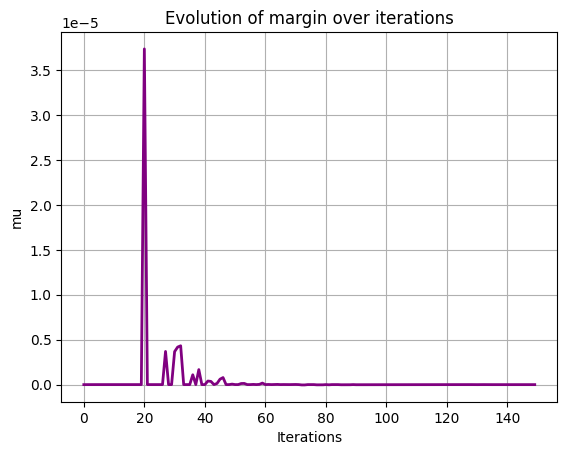

17:06:19 | INFO | machinemoo | Fit runtime: 2888.85 seconds


In [16]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names,
                            model_name = model_name,
                            gradient = False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

In [17]:
objs

array([[3.53304988e-01, 3.62460639e-09],
       [3.52143377e-01, 4.83280858e-09],
       [3.52417721e-01, 4.02734038e-09]])

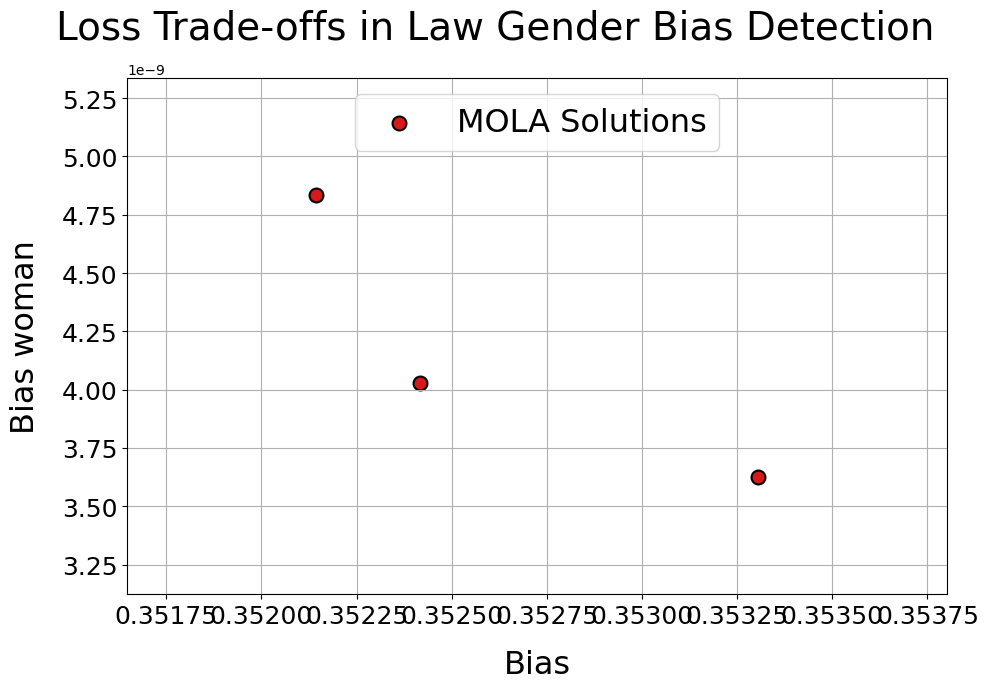

In [18]:
title="Loss Trade-offs in Law Gender Bias Detection"
plot_pareto(methods={'mola': objs},
            labels=task_names, 
            title=title,
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_mola.pdf'
            )

17:06:21 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
17:06:21 | DEBUG | machinemoo | Finding 1th individual minimum
Epoch 1/2 - Training:   0%|          | 0/37 [00:00<?, ?it/s]/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/torch/utils/checkpoint.py:86: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
Evaluating: 100%|██████████| 37/37 [00:07<00:00,  5.26it/s]
17:06:42 | DEBUG | machinemoo | Finding 2th individual minimum
Evaluating: 100%|██████████| 37/37 [00:07<00:00,  5.25it/s]
17:07:03 | INFO | machinemoo | [Lipschitz] Updated global lower bounds: [ -31.31580721 -123.4964379 ]
17:07:03 | DEBUG | machinemoo | Calculated weights: [4.35647926e-11 1.00000000e+00]
17:07:03 | DEBUG | machinemoo | Importance: 124.05827412634495
17:07:03 | DEBUG | machinemoo | Global lower bound (y*): [ -31.31580721 -123.496437

new solution added [0.66268423 0.3800385 ]
solution dominated [0.66279722 0.80770029]


17:07:24 | DEBUG | machinemoo | Calculated weights: [0. 1.]
17:07:24 | DEBUG | machinemoo | Importance: 66.8285171943768
17:07:24 | DEBUG | machinemoo | Global lower bound (y*): [-31.31580721 -66.4484787 ]
17:07:24 | DEBUG | machinemoo | Iteration 2
17:07:24 | DEBUG | machinemoo | Solutions list: [array([0.66268423, 0.3800385 ]), array([0.66218962, 0.56183624])]
Evaluating: 100%|██████████| 37/37 [00:06<00:00,  5.32it/s]
17:07:45 | INFO | machinemoo | [Lipschitz] Updated global lower bounds: [ -4.48629134 -20.61376191]


new solution added [0.65600879 0.25048064]
solution dominated [0.66268423 0.3800385 ]
solution dominated [0.66218962 0.56183624]


17:07:45 | DEBUG | machinemoo | Calculated weights: [0. 1.]
17:07:45 | DEBUG | machinemoo | Importance: 20.864242550689017
17:07:45 | DEBUG | machinemoo | Global lower bound (y*): [ -4.48629134 -20.61376191]
17:07:45 | DEBUG | machinemoo | Iteration 3
17:07:45 | DEBUG | machinemoo | Solutions list: [array([0.65600879, 0.25048064])]
Evaluating: 100%|██████████| 37/37 [00:07<00:00,  5.19it/s]
17:08:06 | INFO | machinemoo | [Lipschitz] Updated global lower bounds: [ -9.31336826 -20.61376191]


...

17:58:58 | DEBUG | machinemoo | Calculated weights: [1. 0.]
17:58:58 | DEBUG | machinemoo | Importance: 35.279949770988644
17:58:58 | DEBUG | machinemoo | Global lower bound (y*): [-34.92144314  -2.36742448]
17:58:58 | DEBUG | machinemoo | Iteration 148
17:58:58 | DEBUG | machinemoo | Solutions list: [array([0.35850663, 0.07097549]), array([0.35980821, 0.07085954]), array([0.36290044, 0.07071943]), array([0.3656853 , 0.07055158]), array([0.37926352, 0.07051314]), array([0.39981099, 0.07038107]), array([0.44907207, 0.07035377]), array([0.51388731, 0.07032013]), array([0.57874775, 0.07027827])]
Evaluating: 100%|██████████| 37/37 [00:07<00:00,  5.27it/s]
17:59:19 | INFO | machinemoo | [Lipschitz] Updated global lower bounds: [-34.92144314  -2.36742448]


new solution dominated [0.36602352 0.07106715]


17:59:19 | DEBUG | machinemoo | Calculated weights: [1. 0.]
17:59:19 | DEBUG | machinemoo | Importance: 35.279949770988644
17:59:19 | DEBUG | machinemoo | Global lower bound (y*): [-34.92144314  -2.36742448]
17:59:19 | DEBUG | machinemoo | Iteration 149
17:59:19 | DEBUG | machinemoo | Solutions list: [array([0.35850663, 0.07097549]), array([0.35980821, 0.07085954]), array([0.36290044, 0.07071943]), array([0.3656853 , 0.07055158]), array([0.37926352, 0.07051314]), array([0.39981099, 0.07038107]), array([0.44907207, 0.07035377]), array([0.51388731, 0.07032013]), array([0.57874775, 0.07027827])]
Evaluating: 100%|██████████| 37/37 [00:07<00:00,  5.24it/s]
17:59:41 | INFO | machinemoo | [Lipschitz] Updated global lower bounds: [-34.92144314  -2.36742448]


new solution added [0.35645221 0.07060684]
solution dominated [0.35850663 0.07097549]
solution dominated [0.35980821 0.07085954]
solution dominated [0.36290044 0.07071943]


17:59:41 | DEBUG | machinemoo | Calculated weights: [1. 0.]
17:59:41 | DEBUG | machinemoo | Importance: 35.2778953555468
17:59:41 | DEBUG | machinemoo | Global lower bound (y*): [-34.92144314  -2.36742448]
17:59:41 | DEBUG | machinemoo | Iteration 150
17:59:41 | DEBUG | machinemoo | Solutions list: [array([0.35645221, 0.07060684]), array([0.3656853 , 0.07055158]), array([0.37926352, 0.07051314]), array([0.39981099, 0.07038107]), array([0.44907207, 0.07035377]), array([0.51388731, 0.07032013]), array([0.57874775, 0.07027827])]


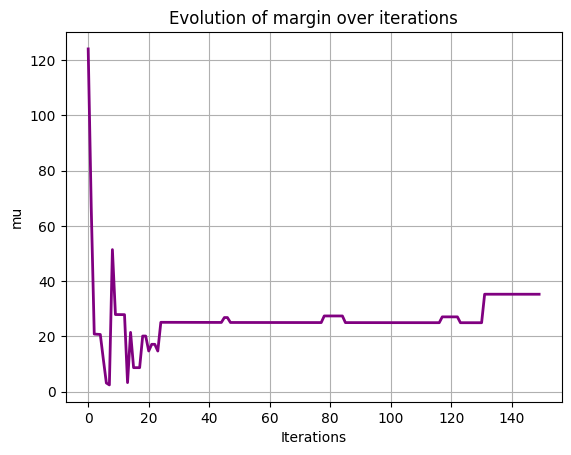

17:59:41 | INFO | machinemoo | Fit runtime: 3200.14 seconds


In [19]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names,
                            model_name=model_name,
                            gradient = True
                            )
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[f'{method}_grad'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

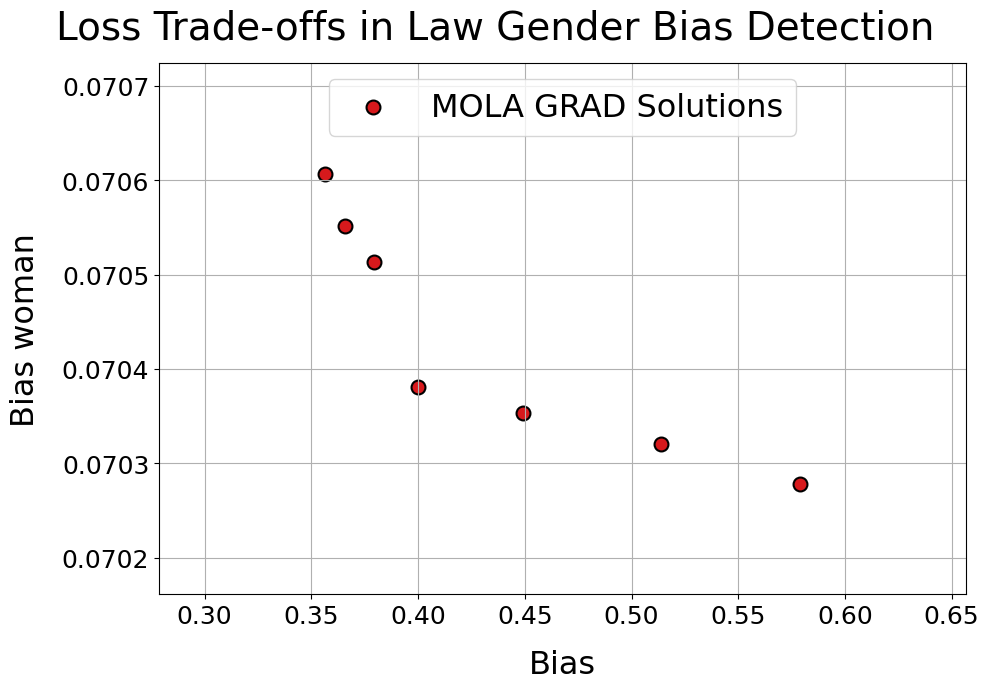

In [20]:
title="Loss Trade-offs in Law Gender Bias Detection"
plot_pareto(methods={'mola_grad': objs},
            labels=task_names, 
            title=title,
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_mola_grad.pdf'
            )

### Random Weights

In [21]:
method = 'random_weight'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names,
                            model_name=model_name, 
                            gradient = False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

17:59:52 | WARNING | machinemoo | Ignored parameters for random_weights: {'nodeTimeLimit', 'targetGap', 'nodeGap'}
17:59:52 | DEBUG | machinemoo | Filtered parameters for random_weights: {'targetSize': 150, 'norm': False}
17:59:52 | DEBUG | machinemoo | Finding 1th individual minima
Epoch 1/2 - Training:   0%|          | 0/37 [00:00<?, ?it/s]/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/torch/utils/checkpoint.py:86: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
Evaluating: 100%|██████████| 37/37 [00:07<00:00,  5.28it/s]
18:00:13 | DEBUG | machinemoo | Finding 2th individual minima
Evaluating: 100%|██████████| 37/37 [00:07<00:00,  5.21it/s]
18:00:55 | DEBUG | machinemoo | 3th solution
Evaluating: 100%|██████████| 37/37 [00:07<00:00,  5.28it/s]
18:01:16 | DEBUG | machinemoo | 4th solution
Evaluating: 100%|██████████| 37/37 [00:07<00:00,  5.26it/s]
18:01:37 | DEBUG | machinemoo | 5th solution
Evaluating: 

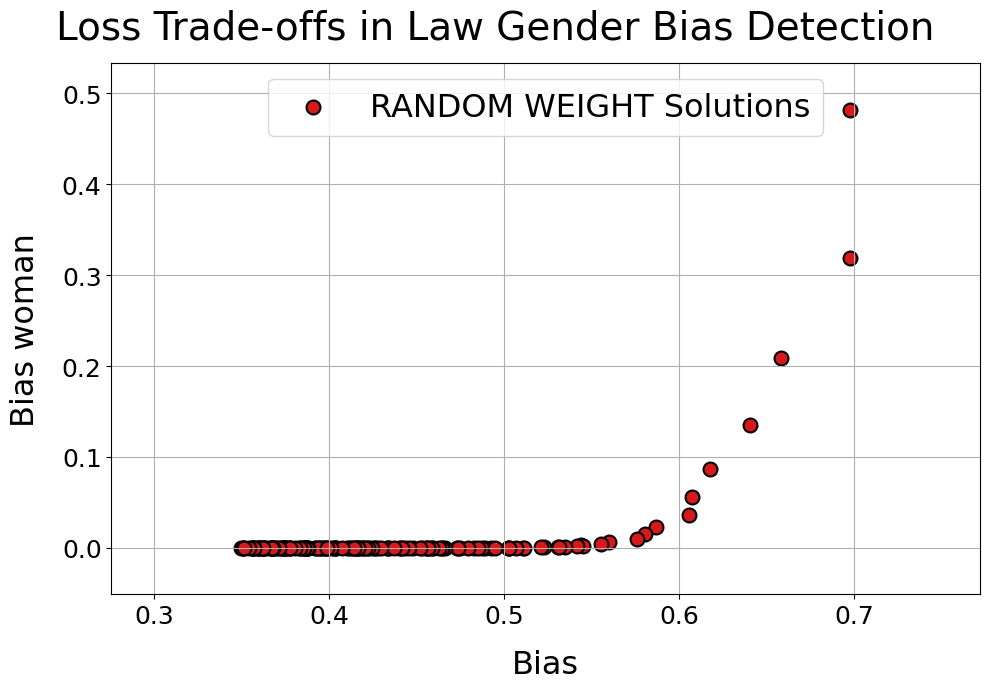

In [22]:
title="Loss Trade-offs in Law Gender Bias Detection"
plot_pareto(methods={'random_weight': objs},
            labels=task_names, 
            title=title,
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_rw.pdf'
            )

## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

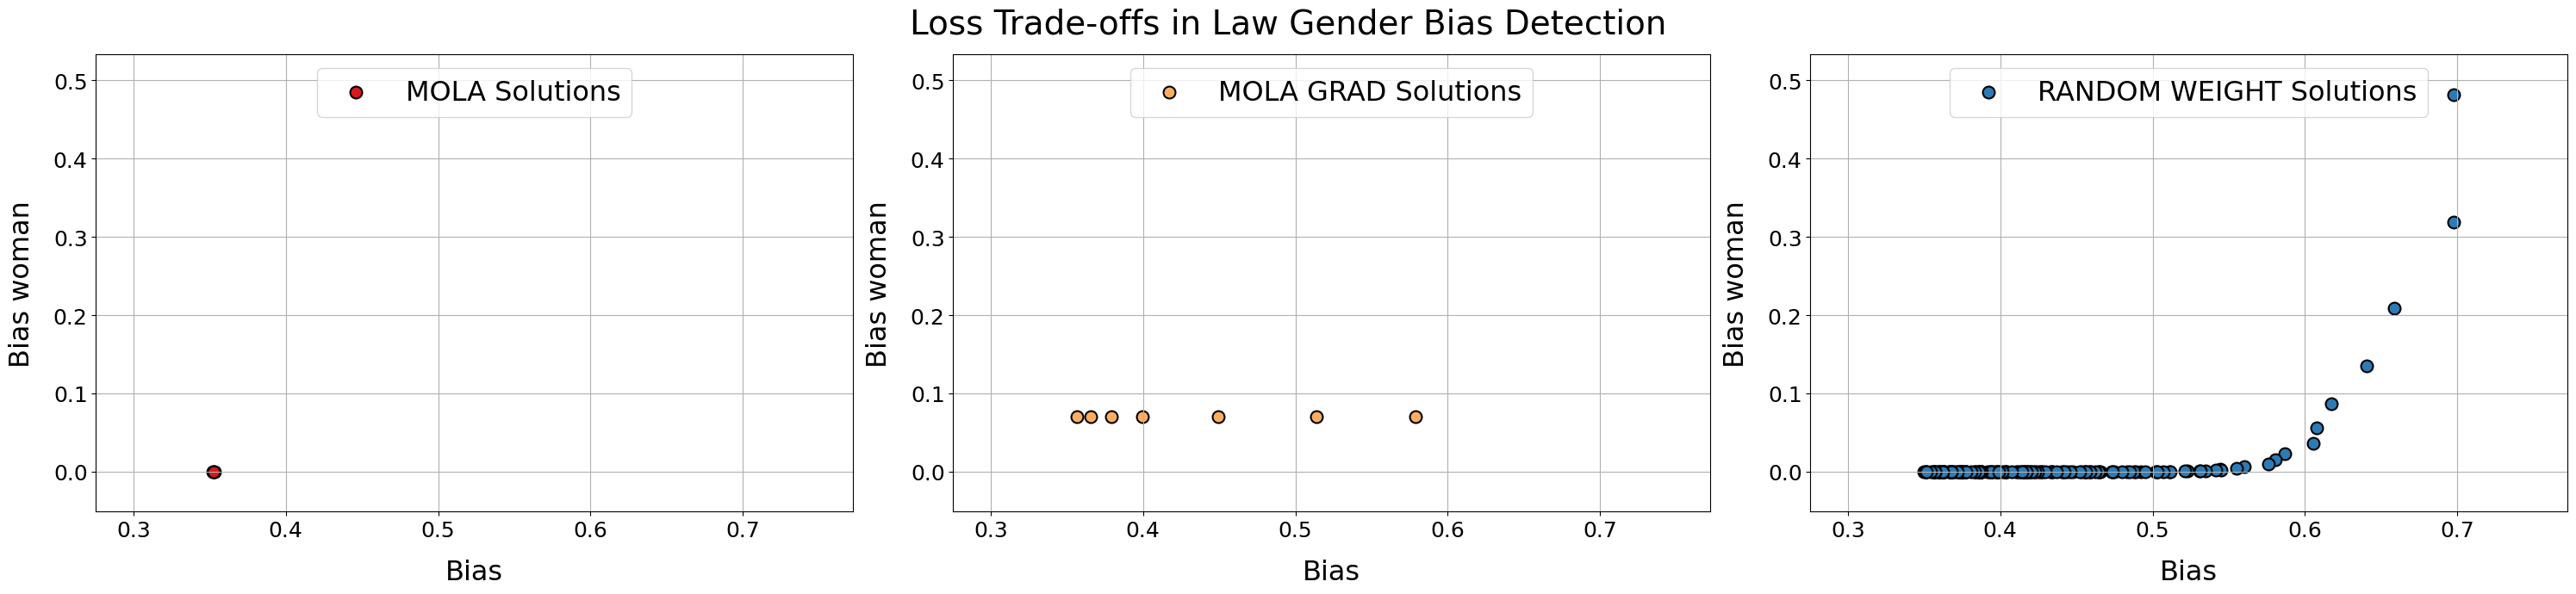

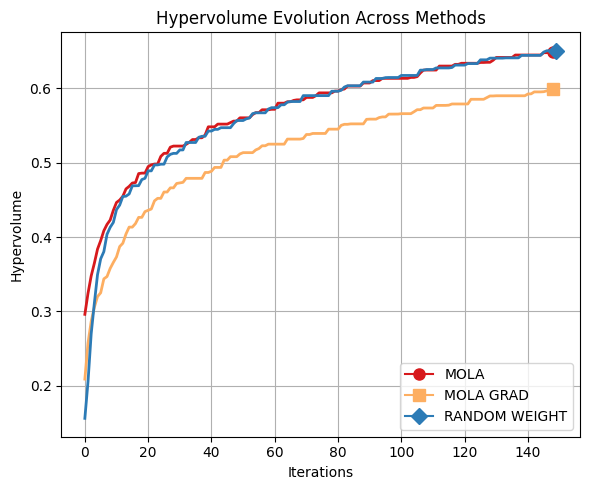

In [23]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

plot_pareto(methods=pareto_dict,
            labels=task_names, 
            title=title,
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_methods.pdf'
            )
plot_multiple_hypervolumes(methods_hv=hypervolumes_dict)

In [24]:
from machinemoo.analysis.visualization import plot_pareto_2d_set_limit

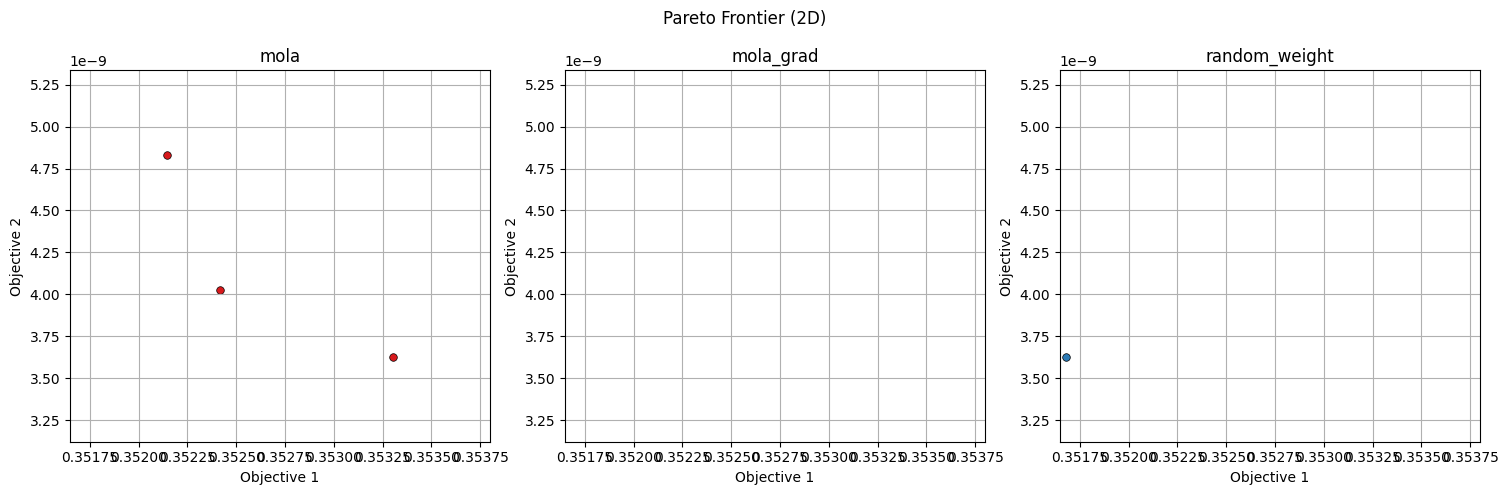

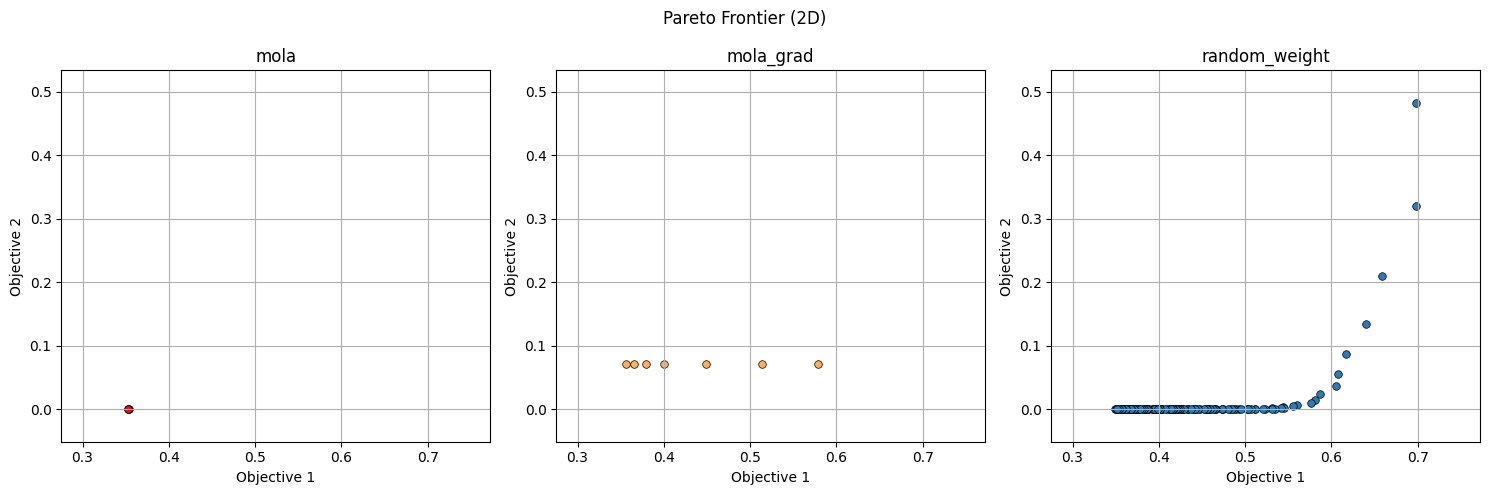

In [25]:
plot_pareto_2d_set_limit(pareto_dict, axis_mode="first")
plot_pareto_2d_set_limit(pareto_dict, axis_mode="global") 